# Week-1 (Book Notation: Features on Rows)

**Note**: In this version, the data matrix $\mathbf{X}$ is of shape $(d, n)$, where $d$ is the number of features (784) and $n$ is the number of samples (100).

## Dataset

We generate the data-matrix $\mathbf{X}$ of shape $(d, n)$. Each column represents one image.

In [ ]:
import numpy as np
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Select 100 samples of digit '2' and reshape to (d, n)
X = X_train[y_train == 2][:100].reshape(-1, 28 * 28).T ## Reshape to (d, n) where d=784 and n=100  { book notation }

# Prepare a test image as a column vector (d, 1)
test_image_vector = X_test[y_test == 2][0].reshape(28 * 28, 1)

d, n = X.shape 
print(f"Matrix X shape: {X.shape}") # Expected (784, 100)

Matrix X shape: (784, 100)


## Problem-1: Mean of the Dataset

Compute the mean vector $\mathbf{\mu}$. Since features are on rows, we average across the columns (axis=1).

In [ ]:
# Compute mean across columns (each data point is a column)
mu = np.mean(X, axis=1, keepdims=True)
print(f"Mean vector shape: {mu.shape}") # Expected (784, 1)

Mean vector shape: (784, 1)


## Problem-2: Centered Dataset

Subtract the mean vector from every column in $\mathbf{X}$.

In [3]:
X_prime = X - mu
print(f"Centered matrix shape: {X_prime.shape}")

Centered matrix shape: (784, 100)


## Problem-5: Covariance Matrix

Compute the covariance matrix $\mathbf{C}$. With features on rows, we use `rowvar=True`.

In [ ]:
# rowvar=True: rows are variables (features), columns are observations
C = np.cov(X_prime) ## rowvar=True bydefault, so each row is a variable (feature) and each column is an observation (data point)
print(f"Covariance matrix shape: {C.shape}") # Expected (784, 784)
print(np.real(C)[235:240, 235:240]) # Print some extracts of the covariance matrix to check values

Covariance matrix shape: (784, 784)
[[11510.13929293 10436.45282828  8677.88545455  6263.63878788
   4362.12121212]
 [10436.45282828 12935.44353535 11316.30121212  7729.12606061
   4884.43434343]
 [ 8677.88545455 11316.30121212 11904.23878788  9256.54505051
   6348.53535354]
 [ 6263.63878788  7729.12606061  9256.54505051 11004.84282828
   9303.56565657]
 [ 4362.12121212  4884.43434343  6348.53535354  9303.56565657
  11438.14141414]]


## Problem-6: Principal Components

Compute eigenvectors of $\mathbf{C}$.

In [24]:
eigen_values, eigen_vectors = np.linalg.eigh(C)

# Sort in descending order of eigenvalues
sorted_indices = np.argsort(eigen_values)[::-1]
sorted_eigen_values = eigen_values[sorted_indices]
sorted_eigen_vectors = eigen_vectors[:, sorted_indices]

w1 = sorted_eigen_vectors[:, 0]
w2 = sorted_eigen_vectors[:, 1]

## Problem-9: Reconstruction

Reconstruct the `test_image` using top $k$ components.

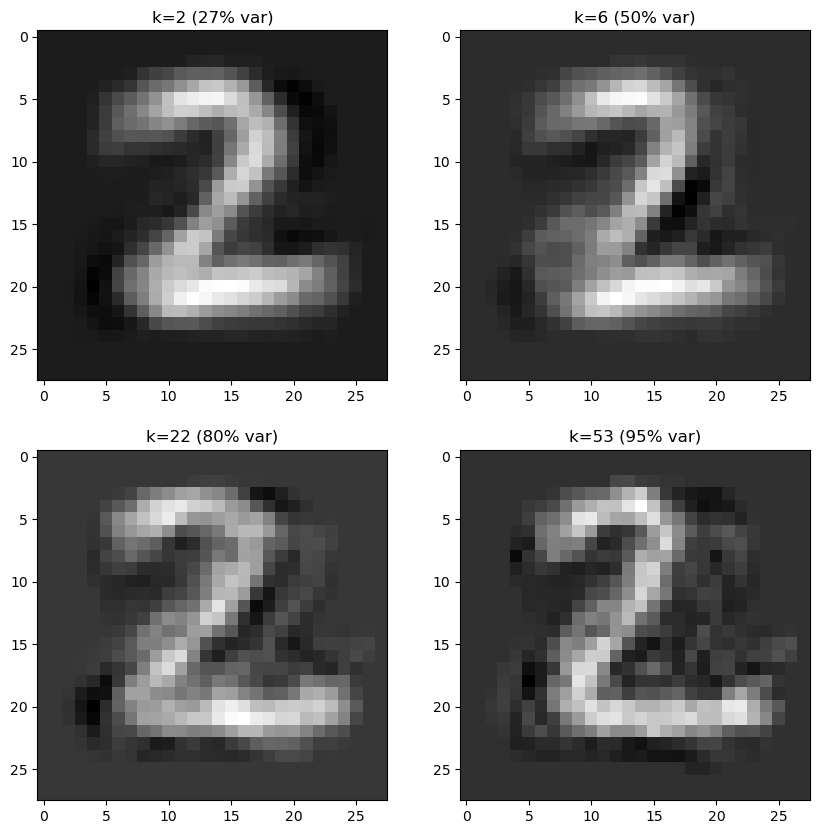

In [25]:
import matplotlib.pyplot as plt

variance_ratio = sorted_eigen_values / np.sum(sorted_eigen_values)
cumulative_variance = np.cumsum(variance_ratio)

k_values = [np.argmax(cumulative_variance >= t) + 1 for t in [0.2, 0.5, 0.8, 0.95]]
test_image_centered = test_image_vector - mu

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for i, k in enumerate(k_values):
    W_k = sorted_eigen_vectors[:, :k]
    
    # Project: (k, d) @ (d, 1) -> (k, 1)
    projected = np.dot(W_k.T, test_image_centered)
    
    # Reconstruct: (d, k) @ (k, 1) + (d, 1) -> (d, 1)
    reconstructed = np.dot(W_k, projected) + mu
    
    img = np.real(reconstructed).reshape(28, 28)
    axs[i//2, i%2].imshow(img, cmap='gray')
    axs[i//2, i%2].set_title(f"k={k} ({int(cumulative_variance[k-1]*100)}% var)")
plt.show()